📊 Generating Individual Training and Validation Line Graphs...


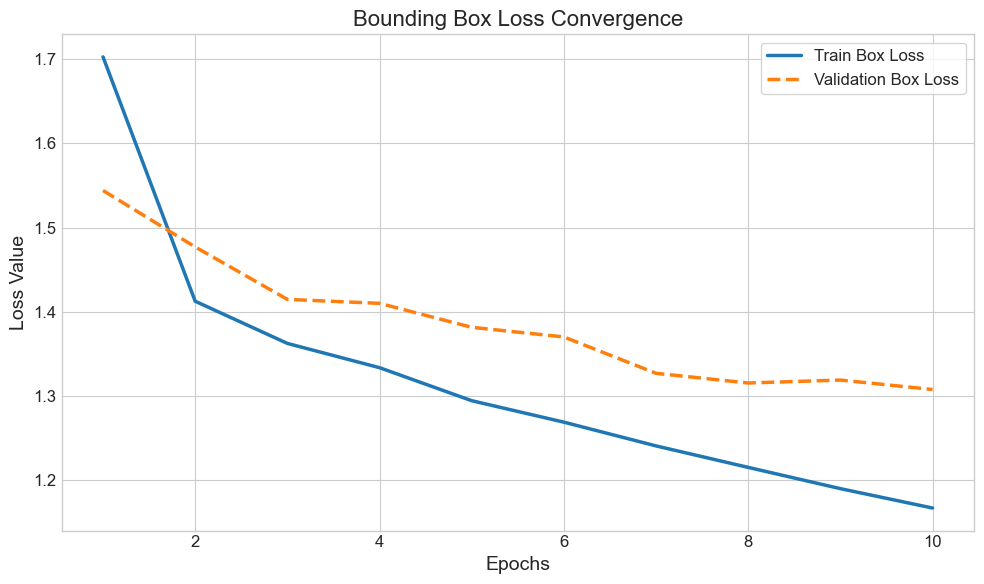

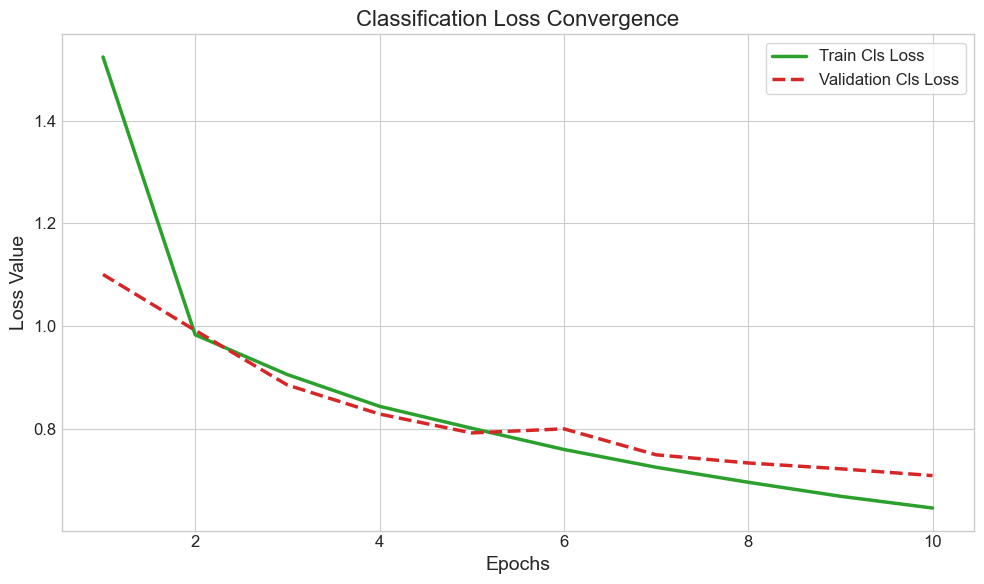

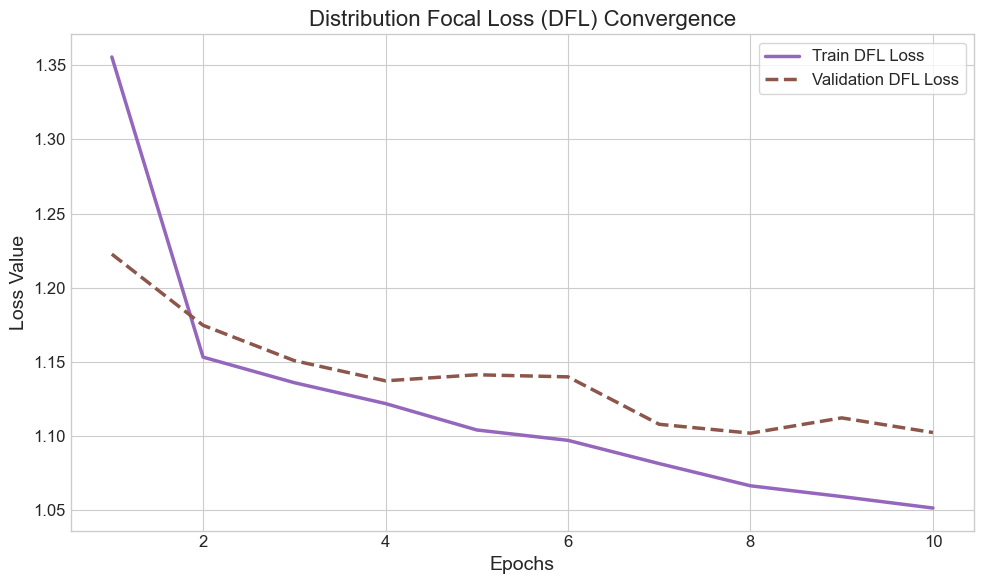

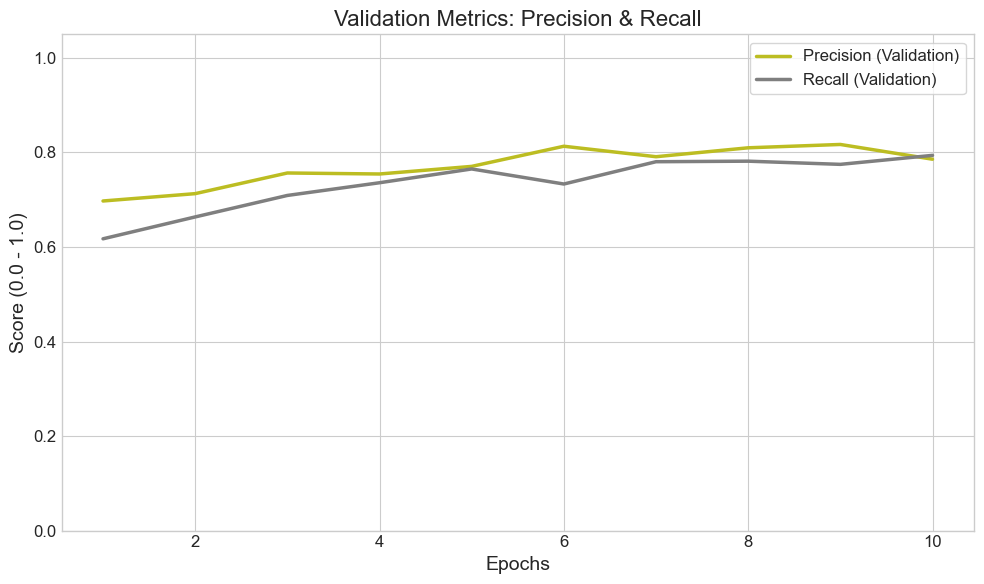

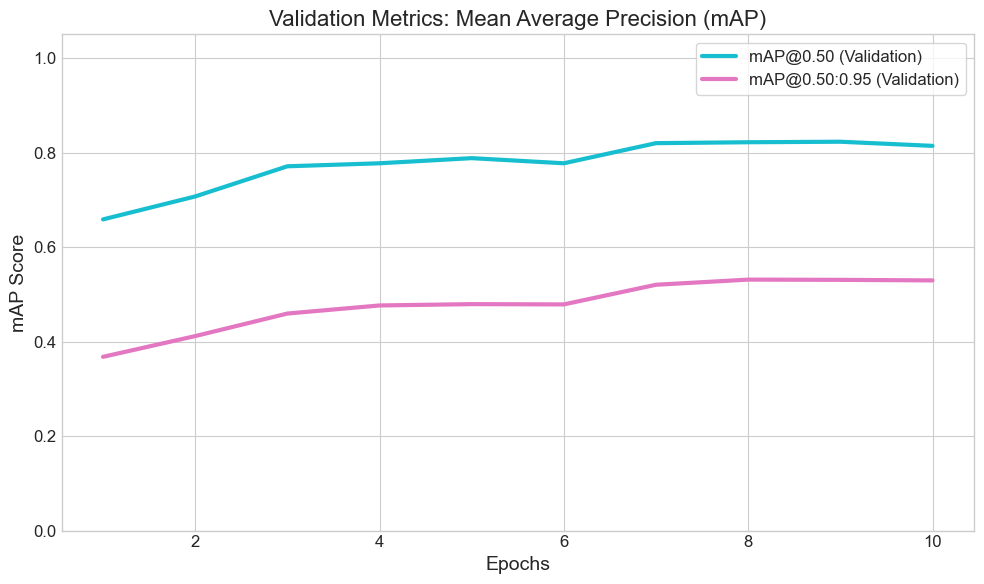

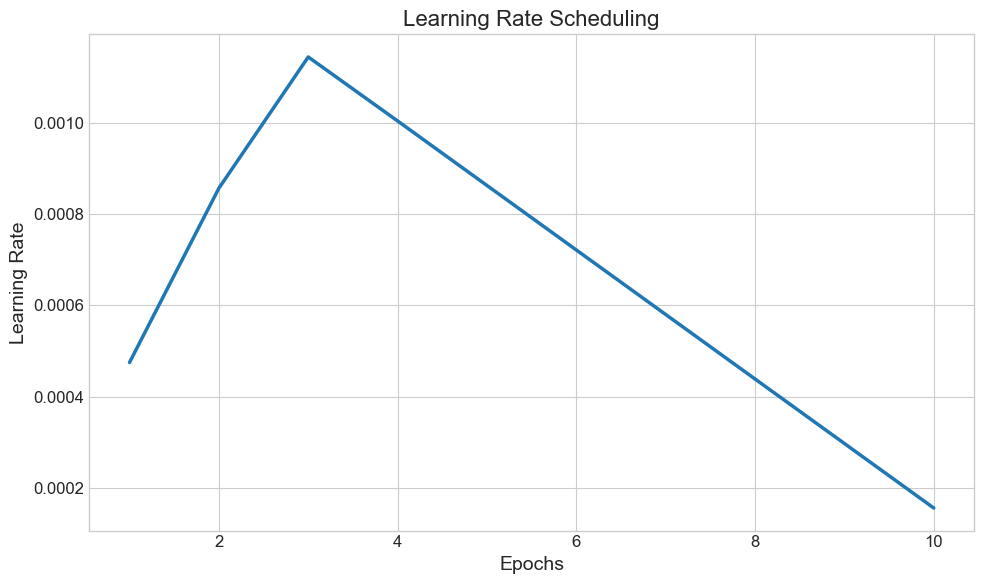

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set standard styling for clean English plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Training Log Path
csv_path = '/Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/train-13/results.csv'

if os.path.exists(csv_path):
    # Load data and strip whitespace from column names
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Handle dynamic column names in YOLOv8
    prec_col = 'metrics/precision(B)' if 'metrics/precision(B)' in df.columns else [col for col in df.columns if 'precision' in col.lower()][0]
    rec_col = 'metrics/recall(B)' if 'metrics/recall(B)' in df.columns else [col for col in df.columns if 'recall' in col.lower()][0]
    lr_col = 'lr/pg0' if 'lr/pg0' in df.columns else [col for col in df.columns if 'lr' in col.lower()][0]

    print("📊 Generating Individual Training and Validation Line Graphs...")

    # ==========================================
    # Plot 1: Box Loss (Train vs Validation)
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#1f77b4', linewidth=2.5)
    plt.plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss', color='#ff7f0e', linestyle='--', linewidth=2.5)
    plt.title('Bounding Box Loss Convergence')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 2: Classification Loss (Train vs Validation)
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='#2ca02c', linewidth=2.5)
    plt.plot(df['epoch'], df['val/cls_loss'], label='Validation Cls Loss', color='#d62728', linestyle='--', linewidth=2.5)
    plt.title('Classification Loss Convergence')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 3: DFL Loss (Train vs Validation)
    # ==========================================
    if 'train/dfl_loss' in df.columns and 'val/dfl_loss' in df.columns:
        plt.figure(figsize=(10, 6))
        plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color='#9467bd', linewidth=2.5)
        plt.plot(df['epoch'], df['val/dfl_loss'], label='Validation DFL Loss', color='#8c564b', linestyle='--', linewidth=2.5)
        plt.title('Distribution Focal Loss (DFL) Convergence')
        plt.xlabel('Epochs')
        plt.ylabel('Loss Value')
        plt.legend(frameon=True)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # Plot 4: Precision & Recall (Validation)
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df[prec_col], label='Precision (Validation)', color='#bcbd22', linewidth=2.5)
    plt.plot(df['epoch'], df[rec_col], label='Recall (Validation)', color='#7f7f7f', linewidth=2.5)
    plt.title('Validation Metrics: Precision & Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Score (0.0 - 1.0)')
    plt.ylim(0, 1.05)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 5: mAP Scores (Validation)
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.50 (Validation)', color='#17becf', linewidth=3.0)
    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.50:0.95 (Validation)', color='#e377c2', linewidth=3.0)
    plt.title('Validation Metrics: Mean Average Precision (mAP)')
    plt.xlabel('Epochs')
    plt.ylabel('mAP Score')
    plt.ylim(0, 1.05)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Plot 6: Learning Rate
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(df['epoch'], df[lr_col], color='#1f77b4', linewidth=2.5)
    plt.title('Learning Rate Scheduling')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Error: 'results.csv' file not found at: {csv_path}")

🚀 Loading CoreML model: /Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/tune_medium/weights/best.mlpackage
Loading /Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/tune_medium/weights/best.mlpackage for CoreML inference...
Loading /Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/tune_medium/weights/best.mlpackage for CoreML inference...
📌 Model class mapping verified: {0: 'Bus', 1: 'Truck', 2: 'Car'}
🧐 Searching through 458 images to find photos containing ALL 3 classes simultaneously...
Loading /Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/tune_medium/weights/best.mlpackage for CoreML inference...
   ... Processed 50/458 images (Found 15 suitable images so far)
   ... Processed 100/458 images (Found 29 suitable images so far)
   ... Processed 150/458 images (Found 37 suitable images so far)
   ... Processed 200/458 images (Found 48 suitable images so far)
   ... Processed 250/458 images (Found 60 suitable images so far)
   ... Processed 300/

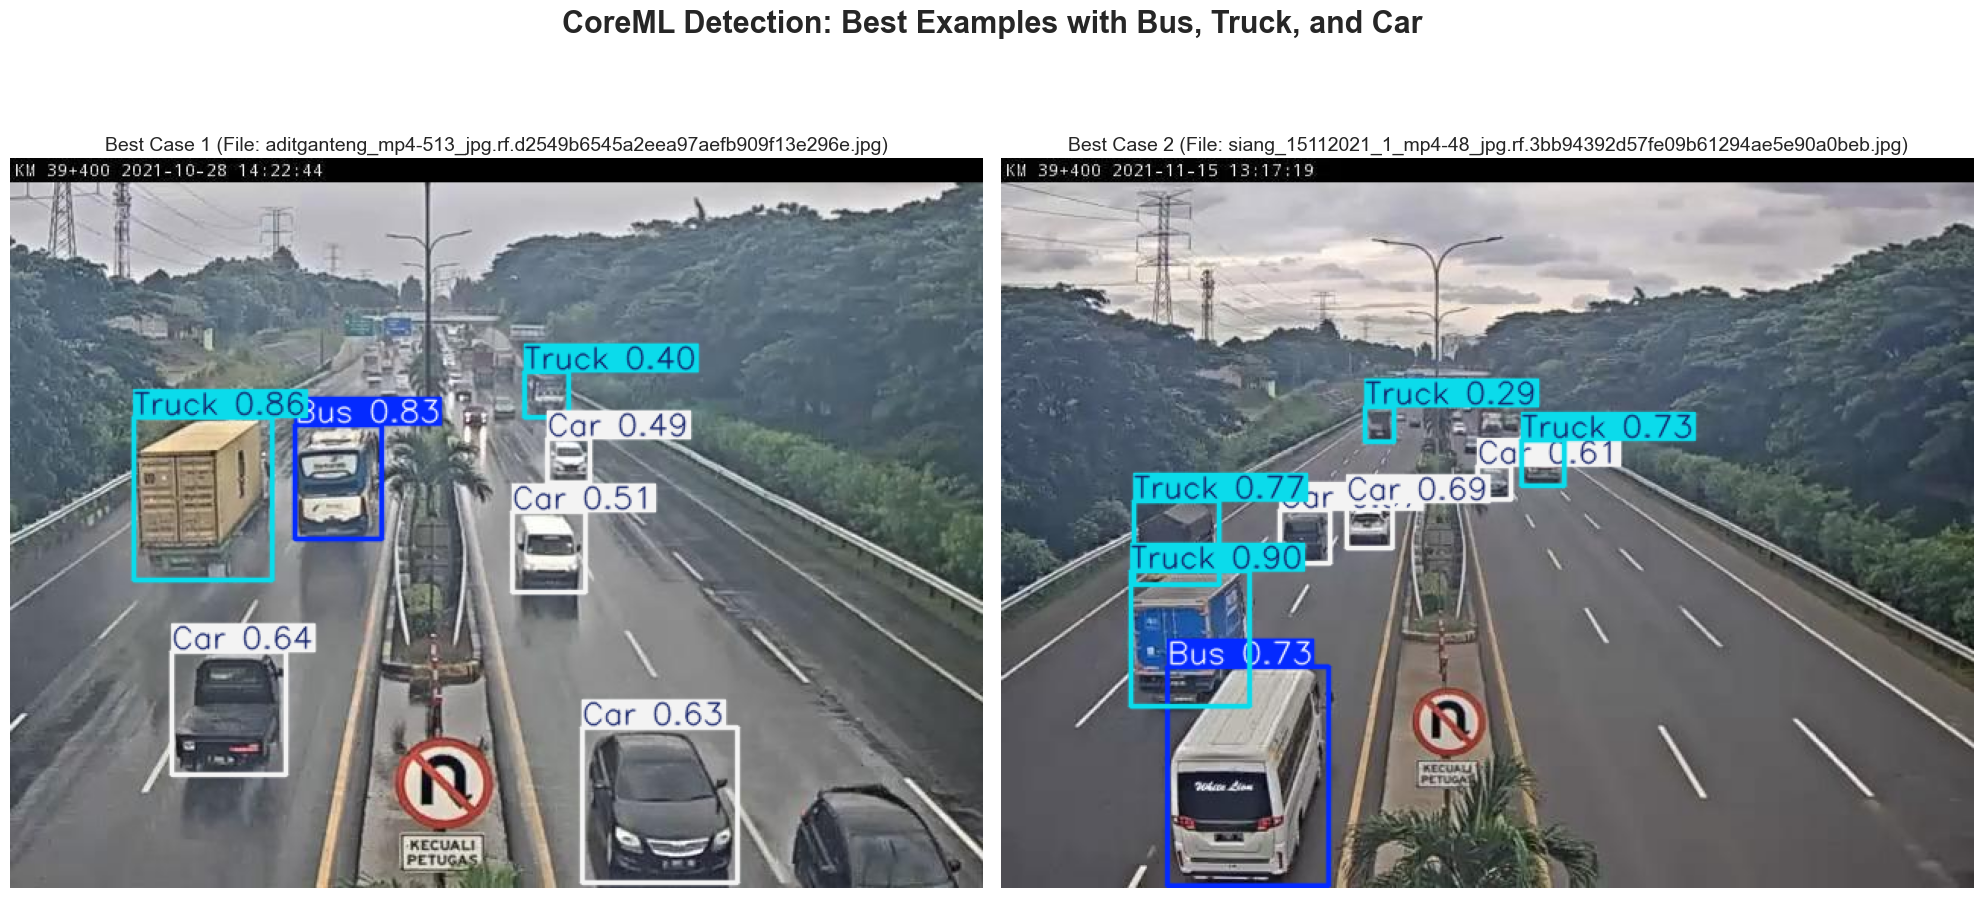

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# CoreML model path from your previous training logs
coreml_model_path = '/Users/gyuminkang/Desktop/YOLO/runs/detect/runs/tune_cells/tune_medium/weights/best.mlpackage'

# Test images directory
test_dir = '/Users/gyuminkang/Desktop/YOLO/test/images/'

def get_class_balance_score(result, target_classes):
    """
    Checks if all 3 target classes exist in the detection result.
    If they do, assigns a higher score to images where the classes are evenly distributed.
    """
    counts = {cls_id: 0 for cls_id in target_classes}
    
    if result.boxes is None or len(result.boxes) == 0:
        return 0
    
    # Count the number of detections for each class
    detected_classes = result.boxes.cls.cpu().numpy().astype(int)
    for cls_id in detected_classes:
        if cls_id in target_classes:
            counts[cls_id] += 1
            
    # ★ CORE LOGIC 1: If ANY of the 3 classes is missing (count is 0), immediately drop it (score 0)
    if any(count == 0 for count in counts.values()):
        return 0
    
    # ★ CORE LOGIC 2: If all 3 classes are present, calculate how balanced they are (Standard Deviation)
    count_values = list(counts.values())
    std_dev = np.std(count_values)
    
    # The smaller the standard deviation (more evenly distributed), the higher the score
    balance_score = 1 / (1 + std_dev)
    
    return balance_score

if os.path.exists(test_dir) and os.path.exists(coreml_model_path):
    # 1. Load the CoreML model (Load early to extract dynamic class IDs)
    print(f"🚀 Loading CoreML model: {coreml_model_path}")
    model = YOLO(coreml_model_path)
    
    # Extract the actual class IDs trained in your custom model (e.g., [0, 1, 2])
    target_classes = list(model.names.keys())
    print(f"📌 Model class mapping verified: {model.names}")

    # 2. Get all images in the test directory
    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.lower().endswith(valid_extensions)]
    
    if not all_test_images:
        print(f"❌ No images found in the test directory ({test_dir}).")
        exit()

    print(f"🧐 Searching through {len(all_test_images)} images to find photos containing ALL 3 classes simultaneously...")

    scored_results = []
    
    # 3. Run inference on all images and check conditions
    for i, img_path in enumerate(all_test_images):
        try:
            results = model(img_path, verbose=False)
            for result in results:
                # Check if all 3 classes exist
                score = get_class_balance_score(result, target_classes)
                if score > 0: 
                    scored_results.append((score, result))
                    
        except Exception as e:
            pass # Silently skip images that cause errors
        
        # Display progress every 50 images
        if (i + 1) % 50 == 0:
            print(f"   ... Processed {i + 1}/{len(all_test_images)} images (Found {len(scored_results)} suitable images so far)")

    # 4. Sort in descending order based on the balance score
    scored_results.sort(key=lambda x: x[0], reverse=True)

    # 5. Visualize the top 2 most balanced results
    num_to_show = min(2, len(scored_results))
    
    if num_to_show > 0:
        print(f"\n✅ Search complete! Visualizing the top {num_to_show} images containing all 3 classes.")
        
        fig, axes = plt.subplots(1, num_to_show, figsize=(20, 10))
        fig.suptitle('CoreML Detection: Best Examples with Bus, Truck, and Car', fontsize=22, fontweight='bold')

        # Handle edge case where only 1 image is found
        if num_to_show == 1:
            axes = [axes]

        for i in range(num_to_show):
            score, result = scored_results[i]
            img_path = result.path
            
            # Convert BGR to RGB for correct matplotlib color rendering
            img_bgr = result.plot() 
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Best Case {i+1} (File: {os.path.basename(img_path)})", fontsize=14)
            axes[i].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print("\n❌ Explored all images, but couldn't find a single image containing a Bus, Truck, and Car simultaneously. Please verify your test dataset diversity.")

else:
    print("❌ Could not find the model file or test image directory. Please check the paths.")